# 01 - Exploratory Data Analysis & Base Map
Visualizing the final merged dataset containing Dengue and Cholera cases along with climate features.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('ggplot')
sns.set_palette('husl')

# Load the final dataset
df = pd.read_csv('../data/processed/final_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1025, 11)


,country_code,year,country_name,region,dengue_cases,cholera_cases,temp_max_c,temp_min_c,temp_mean_c,precipitation_mm,rain_mm
0,AFG,2000,Afghanistan,Eastern Mediterranean,0.0,4330.0,12.176503,-1.479508,5.816667,205.4,51.8
1,AFG,2001,Afghanistan,Eastern Mediterranean,0.0,4499.0,12.750685,-0.612055,6.486301,221.0,101.7
2,AFG,2002,Afghanistan,Eastern Mediterranean,0.0,3.0,11.881370,-1.024932,5.875616,386.6,157.3
3,AFG,2003,Afghanistan,Eastern Mediterranean,0.0,41.0,11.011781,-1.601918,5.172603,415.9,152.0
4,AFG,2005,Afghanistan,Eastern Mediterranean,0.0,33.0,10.248767,-1.871781,4.538082,458.2,200.5


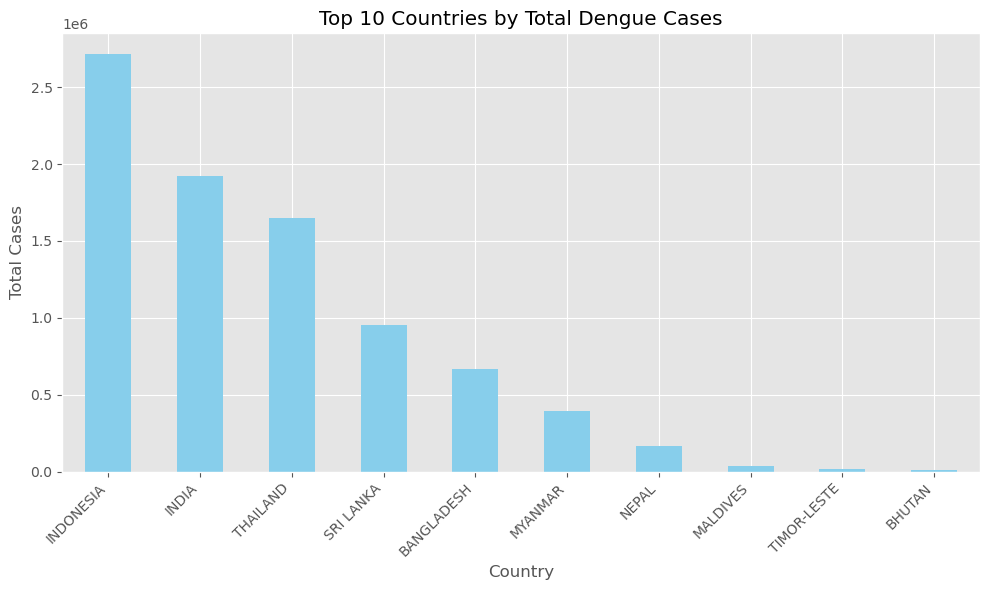

In [14]:
# 1. Bar chart — Top 10 countries by total Dengue cases
top_dengue = df.groupby('country_name')['dengue_cases'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_dengue.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Total Dengue Cases')
plt.ylabel('Total Cases')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


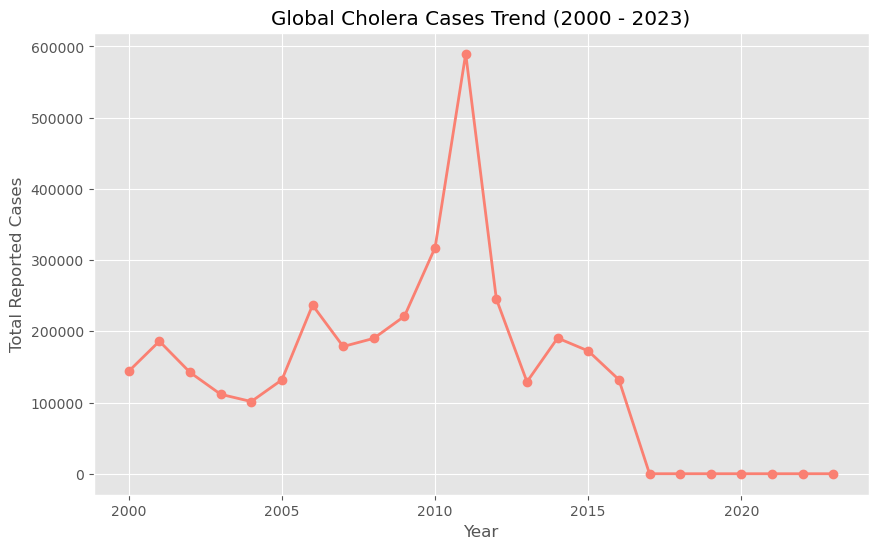

In [15]:
# 2. Line chart — Global Cholera cases trend from 2000 to 2023
cholera_trend = df[(df['year'] >= 2000) & (df['year'] <= 2023)].groupby('year')['cholera_cases'].sum()

plt.figure(figsize=(10, 6))
plt.plot(cholera_trend.index, cholera_trend.values, marker='o', color='salmon', linewidth=2)
plt.title('Global Cholera Cases Trend (2000 - 2023)')
plt.xlabel('Year')
plt.ylabel('Total Reported Cases')
plt.grid(True)
plt.show()


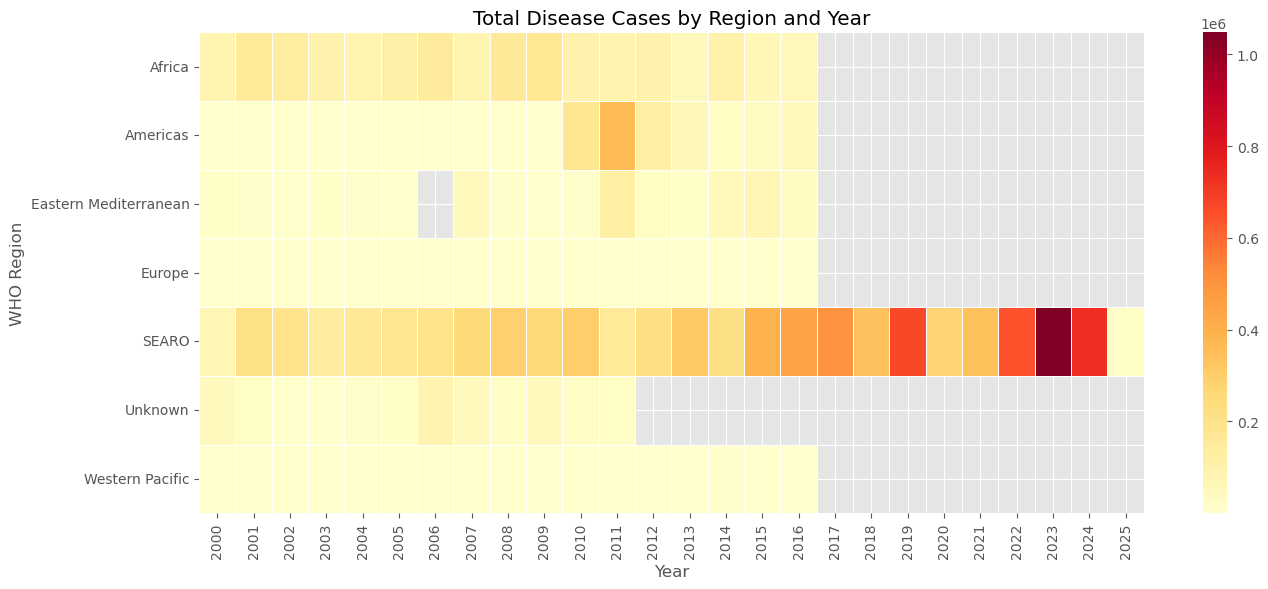

In [16]:
# 3. Heatmap — cases by region and year
# We will combine Dengue and Cholera for total outbreak activity
df['total_cases'] = df['dengue_cases'].fillna(0) + df['cholera_cases'].fillna(0)
heatmap_data = df.pivot_table(values='total_cases', index='region', columns='year', aggfunc='sum')

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5, annot=False)
plt.title('Total Disease Cases by Region and Year')
plt.xlabel('Year')
plt.ylabel('WHO Region')
plt.tight_layout()
plt.show()


In [17]:
# 4. Folium choropleth world map — countries colored by total Dengue cases

# Load world map from local downloaded shapefile
world = gpd.read_file('../data/raw/ne_110m_admin_0_countries.zip')
world.columns = world.columns.str.lower() # ensure iso_a3 is lowercase

# Calculate total Dengue cases per country for mapping
map_data = df.groupby('country_code')['dengue_cases'].sum().reset_index()

# Merge map data with geometries
world_data = world.merge(map_data, how='left', left_on='iso_a3', right_on='country_code')
world_data['dengue_cases'] = world_data['dengue_cases'].fillna(0)

# Create a base map using Folium
m = folium.Map(location=[20, 0], zoom_start=2, tiles='cartodb positron')

# Add Dengue Choropleth
folium.Choropleth(
    geo_data=world,
    name='Dengue Cases',
    data=world_data,
    columns=['iso_a3', 'dengue_cases'],
    key_on='feature.properties.iso_a3',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Total Dengue Cases'
).add_to(m)

folium.LayerControl().add_to(m)

# Display the map
m
